# Iris Dataset Classification Project

## Description

***The Iris Dataset***

The Iris dataset is a classic benchmark in machine learning: it contains 150 flower samples from three species (*Setosa*, *Versicolor*, *Virginica*), each described by four numeric features — **sepal length, sepal width, petal length, and petal width**. It is widely used for testing classification algorithms.

---

***Key Facts***
- **Origin**: Introduced by British statistician Ronald Fisher in 1936 in his paper on linear discriminant analysis.
- **Species**:
  - *Iris setosa*
  - *Iris versicolor*
  - *Iris virginica*
- **Samples**: 50 flowers per species → **150 total samples**
- **Features (cm)**:
  - Sepal length
  - Sepal width
  - Petal length
  - Petal width
- **Task**: Predict the species of iris flower based on these four features.

---

***Why It’s Important**
- **Beginner‑friendly**: Small, clean dataset ideal for learning classification.
- **Balanced classes**: Each species has equal representation.
- **Linearly separable**: Setosa is easily distinguished, while Versicolor and Virginica overlap more.
- **Applications**:
  - Testing algorithms (Logistic Regression, SVM, Decision Trees, XGBoost)
  - Demonstrating preprocessing, feature selection, and evaluation metrics
  - Visualizations (scatter plots, pair plots) to show separability of classes

---

***Example Use Cases***
- **Classification**: Train models to predict species.
- **Feature importance**: Identify which features (petal length/width) are most discriminative.
- **Dimensionality reduction**: Apply PCA to visualize in 2D.
- **Clustering**: Use k‑means to group flowers without labels.

---

***Quick Insights***
- **Petal length and petal width** are the most informative features for distinguishing species.
- **Sepal features** are less discriminative but still useful.
- The dataset is small enough to run quickly on any laptop, making it perfect for tutorials and experiments.


## Steps Overview

1. **Data Loading & Preprocessing**
   - Load Iris dataset (`sklearn.datasets.load_iris`).
   - Split into train/test (80/20).
   - Standardize features (`StandardScaler`).
   - Optional: Encode labels if needed.

2. **Feature Selection**
   - Use `SelectKBest` or `Recursive Feature Elimination (RFE)` to identify most informative features.
   - Compare performance with/without feature selection.

3. **Models to Train**
   - Logistic Regression
   - Support Vector Machine (SVM)
   - Decision Tree
   - XGBoost

4. **Cross‑Validation & Grid Search**
   - Apply `GridSearchCV` with 5‑fold cross‑validation.
   - Tune hyperparameters for each model (e.g., C for SVM, max_depth for Decision Tree, learning_rate for XGBoost).

5. **Evaluation Metrics**
   - Accuracy
   - Precision
   - Recall
   - F1‑Score
   - Matthews Correlation Coefficient (MCC)

6. **Visualization**
   - Confusion matrices for each model.
   - Bar plots comparing metrics across models.
   - Feature importance plots (Decision Tree, XGBoost).

## Load Libraries

***Explanation of Imported Modules and Datasets***

This notebook uses several Python libraries to build and evaluate classification models on the Iris dataset. Below is the rationale behind each import:

---

***Core Libraries***
- **numpy**: Provides numerical operations and array handling. Essential for manipulating feature matrices and labels.
- **matplotlib.pyplot**: Used for plotting graphs, confusion matrices, and feature importance visualizations.
- **seaborn**: High-level visualization library built on matplotlib. Helps create attractive plots (e.g., heatmaps, pair plots).

---

***Dataset***
- **sklearn.datasets.load_iris**: Loads the Iris dataset, a classic benchmark in machine learning with 150 samples of three flower species (*Setosa, Versicolor, Virginica*). Each sample has four features (sepal length, sepal width, petal length, petal width).  
  **Reason**: Provides a clean, balanced dataset ideal for testing classification algorithms.

---

***Model Selection & Validation***
- **train_test_split**: Splits the dataset into training and testing sets (e.g., 80/20).  
  **Reason**: Ensures models are trained on one subset and evaluated on unseen data.
- **GridSearchCV**: Performs exhaustive search over hyperparameter grids with cross-validation.  
  **Reason**: Finds the best hyperparameters for each model.
- **cross_val_score**: Evaluates models using k-fold cross-validation.  
  **Reason**: Provides more reliable performance estimates.

---

***Preprocessing & Feature Selection***
- **StandardScaler**: Standardizes features (mean=0, variance=1).  
  **Reason**: Improves performance of algorithms sensitive to feature scaling (e.g., SVM, Logistic Regression).
- **SelectKBest, f_classif**: Selects the top k features based on ANOVA F-test.  
  **Reason**: Reduces dimensionality and highlights the most discriminative features.

---

***Metrics & Evaluation***
- **accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef**: Standard classification metrics.  
  **Reason**: Provide a comprehensive evaluation of model performance.
- **ConfusionMatrixDisplay**: Visualizes confusion matrices.  
  **Reason**: Shows how well models classify each species.

---

***Models***
- **LogisticRegression**: Linear model for classification.  
  **Reason**: Simple, interpretable baseline.
- **SVC (Support Vector Classifier)**: Finds optimal hyperplanes for classification.  
  **Reason**: Powerful for small datasets with clear margins.
- **DecisionTreeClassifier**: Splits data based on feature thresholds.  
  **Reason**: Easy to interpret, provides feature importance.
- **xgboost.XGBClassifier**: Gradient boosting algorithm.  
  **Reason**: Strong performance on structured/tabular data, provides feature importance.

---

***Summary***
Each import plays a specific role:
- **Data handling** → `numpy`, `load_iris`
- **Visualization** → `matplotlib`, `seaborn`, `ConfusionMatrixDisplay`
- **Preprocessing** → `StandardScaler`, `SelectKBest`
- **Modeling** → `LogisticRegression`, `SVC`, `DecisionTreeClassifier`, `XGBClassifier`
- **Evaluation** → metrics + cross-validation tools

Together, they form a complete pipeline for training, tuning, and evaluating classification models on the Iris dataset.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, ConfusionMatrixDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
import xgboost as xgb

## Load data

In [2]:
iris = load_iris() #load
X, y = iris.data, iris.target #data contain 150 samples and target represent the species
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y #stratify to ensure that the class distribution is preserved
)  #split data into training and testing subsets

## Preprocessing

`StandardScaler` standardizes features by removing the mean and scaling to unit variance.



$$ 
x' = \frac{x - \mu}{\sigma}
$$



where:  
- $\mu$ = mean of the feature (calculated from training data)  
- $\sigma$ = standard deviation of the feature (calculated from training data)  

This ensures each feature has mean 0 and variance 1.

---

### 🔹 Step-by-step

**scaler = StandardScaler()**  
Creates a scaler object that will learn the mean and standard deviation.

**X_train = scaler.fit_transform(X_train)**  
- **Fit**: computes mean and std from $X_{train}$.  
- **Transform**: applies scaling to $X_{train}$.  
- **Result**: training data is standardized.

**X_test = scaler.transform(X_test)**  
- Uses the same mean and std learned from training.  
- Transforms $X_{test}$ without refitting.  
- Prevents data leakage and keeps scaling consistent.


In [3]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Feature selection (keep 2 best features)

`SelectKBest` is a method for feature selection: it picks the top $k$ features based on a scoring function.



$$
\text{score\_func} = f\_classif
$$



This means it uses the ANOVA F-test (Analysis of Variance) to measure how strongly each feature is related to the target variable ($y\_{train}$).



$$
k = 2
$$



This means we want to keep only the 2 best features.

---

### Step-by-step

**selector = SelectKBest(score_func=f_classif, k=2)**  
- Creates a feature selector object.  
- It will evaluate each feature using the ANOVA F-test and rank them.  
- Only the top 2 features will be kept.

**X_train_fs = selector.fit_transform(X_train, y_train)**  
- **Fit**: computes the F-scores for each feature using $X_{train}$ and $y_{train}$.  
- **Transform**: selects the 2 best features and returns a reduced training dataset ($X_{train\_fs}$).

**X_test_fs = selector.transform(X_test)**  
- Applies the same selection (the 2 features chosen from training).  
- Transforms $X_{test}$ to keep only those features.


In [4]:
selector = SelectKBest(score_func=f_classif, k=2)
X_train_fs = selector.fit_transform(X_train, y_train)
X_test_fs = selector.transform(X_test)

## Models and Grids

***Dictionary of Models and Hyperparameter Grids***

That script is building a dictionary of machine learning models and their hyperparameter grids — it’s typically used for model comparison with techniques like `GridSearchCV` or other hyperparameter tuning.  

---

 🔹 Structure of `models`
- Keys are model names (`"LogisticRegression"`, `"SVM"`, etc.).  
- Values are tuples: `(model_object, parameter_grid)`.  

This structure makes it easy to loop through different models and run hyperparameter tuning.

---

🔹 Breakdown by Model

**Logistic Regression**  
- Model: `LogisticRegression(max_iter=200)` → logistic regression with 200 iterations allowed.  
- Parameters: `{"C":[0.1,1,10]}` → tests different values of regularization strength $C$.

**Support Vector Machine (SVM)**  
- Model: `SVC()` → support vector classifier.  
- Parameters:  
  - $C$: regularization strength (0.1, 1, 10).  
  - `kernel`: type of kernel function (`linear`, `rbf`).

**Decision Tree**  
- Model: `DecisionTreeClassifier()`.  
- Parameters: `{"max_depth":[2,3,4,5]}` → tests different tree depths.

**XGBoost**  
- Model: `xgb.XGBClassifier(...)` → gradient boosting classifier.  
- Parameters:  
  - `max_depth`: depth of trees (2, 3, 4).  
  - `learning_rate`: step size shrinkage (0.1, 0.3).  
  - `n_estimators`: number of boosting rounds (50, 100).


In [5]:
models = {
    "LogisticRegression": (LogisticRegression(max_iter=200),
                           {"C":[0.1,1,10]}),
    "SVM": (SVC(),
            {"C":[0.1,1,10], "kernel":["linear","rbf"]}),
    "DecisionTree": (DecisionTreeClassifier(),
                     {"max_depth":[2,3,4,5]}),
    "XGBoost": (xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),
                {"max_depth":[2,3,4], "learning_rate":[0.1,0.3], "n_estimators":[50,100]})
}

***Metrics and Results Dictionaries***

The Python code:



$$
\texttt{metrics = ["Accuracy","Precision","Recall","F1","MCC"]}
$$





$$
\texttt{results\_before = \{\}}
$$





$$
\texttt{results\_after = \{\}}
$$



---

***Explanation***

- **metrics** is a list that contains the names of evaluation metrics commonly used in classification tasks:
Accuracy
Precision
Recall
F1-score
MCC (Matthews Correlation Coefficient)


- **results_before** is an empty dictionary.  
  It is intended to store metric values before applying a certain process (e.g., feature selection, scaling, or model tuning).

- **results_after** is also an empty dictionary.  
  It is intended to store metric values after applying that process.

---

***Purpose***

This setup allows you to:
----Define which metrics will be evaluated.  
----Store results in two separate dictionaries *results_before* and *results_after* for easy comparison.  
----Later, populate these dictionaries with actual metric scores to analyze performance improvements.

In [6]:
metrics = ["Accuracy","Precision","Recall","F1","MCC"]
results_before = {}
results_after = {}

## Train before and after tuning

***Model Training and Evaluation Pipeline***

- **name**: the model name (e.g., "LogisticRegression", "SVM").
- **model**: the model object (e.g., `LogisticRegression()`).
- **params**: the hyperparameter grid for tuning.

**Before tuning (default parameters)**
- Train the model with default parameters.
- Predict on the test set.
- Store evaluation metrics in `results_before[name]`.

**Metrics calculated:**
- Accuracy
- Precision (macro average)
- Recall (macro average)
- F1-score (macro average)
- MCC (Matthews Correlation Coefficient)

**After tuning (GridSearchCV)**
- Perform grid search with cross-validation (`cv=5`).
- Find the best hyperparameters (`grid.best_params_`).
- Train the best model and predict on the test set.
- Store evaluation metrics in `results_after[name]`.

**Print results**
- Displays the best hyperparameters found.
- Shows performance metrics before and after tuning for comparison.

**Purpose** <br>
This code :
1. Compares each model's performance with default setting vs tuned hyperparameters
2. Stores results in two dictionaries (*results_before* and *results_after*)
3. Prints out the best parameters and metrics for easy analysis

In [7]:
for name, (model, params) in models.items():
    # Before tuning (default)
    model.fit(X_train_fs, y_train)
    y_pred_default = model.predict(X_test_fs)
    results_before[name] = {
        "Accuracy": accuracy_score(y_test, y_pred_default),
        "Precision": precision_score(y_test, y_pred_default, average='macro'),
        "Recall": recall_score(y_test, y_pred_default, average='macro'),
        "F1": f1_score(y_test, y_pred_default, average='macro'),
        "MCC": matthews_corrcoef(y_test, y_pred_default)
    }

        # After tuning (GridSearchCV)
    grid = GridSearchCV(model, params, cv=5, scoring='accuracy')
    grid.fit(X_train_fs, y_train)
    best_model = grid.best_estimator_
    y_pred_best = best_model.predict(X_test_fs)
    results_after[name] = {
        "Accuracy": accuracy_score(y_test, y_pred_best),
        "Precision": precision_score(y_test, y_pred_best, average='macro'),
        "Recall": recall_score(y_test, y_pred_best, average='macro'),
        "F1": f1_score(y_test, y_pred_best, average='macro'),
        "MCC": matthews_corrcoef(y_test, y_pred_best)
    }

    print(f"\n{name} best params: {grid.best_params_}")
    print("Before tuning:", results_before[name])
    print("After tuning:", results_after[name])


LogisticRegression best params: {'C': 0.1}
Before tuning: {'Accuracy': 0.9333333333333333, 'Precision': 0.9333333333333332, 'Recall': 0.9333333333333332, 'F1': 0.9333333333333332, 'MCC': 0.9}
After tuning: {'Accuracy': 0.9333333333333333, 'Precision': 0.9333333333333332, 'Recall': 0.9333333333333332, 'F1': 0.9333333333333332, 'MCC': 0.9}

SVM best params: {'C': 0.1, 'kernel': 'linear'}
Before tuning: {'Accuracy': 0.9333333333333333, 'Precision': 0.9333333333333332, 'Recall': 0.9333333333333332, 'F1': 0.9333333333333332, 'MCC': 0.9}
After tuning: {'Accuracy': 0.9333333333333333, 'Precision': 0.9333333333333332, 'Recall': 0.9333333333333332, 'F1': 0.9333333333333332, 'MCC': 0.9}

DecisionTree best params: {'max_depth': 4}
Before tuning: {'Accuracy': 0.9333333333333333, 'Precision': 0.9333333333333332, 'Recall': 0.9333333333333332, 'F1': 0.9333333333333332, 'MCC': 0.9}
After tuning: {'Accuracy': 0.9333333333333333, 'Precision': 0.9333333333333332, 'Recall': 0.9333333333333332, 'F1': 0.93

C:\Users\abidc\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [07:53:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\abidc\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [07:53:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\abidc\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [07:53:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\abidc\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [07:53:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtr


XGBoost best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
Before tuning: {'Accuracy': 0.9666666666666667, 'Precision': 0.9696969696969697, 'Recall': 0.9666666666666667, 'F1': 0.9665831244778612, 'MCC': 0.9515873026942034}
After tuning: {'Accuracy': 0.9666666666666667, 'Precision': 0.9696969696969697, 'Recall': 0.9666666666666667, 'F1': 0.9665831244778612, 'MCC': 0.9515873026942034}


## Plot comparison

**1. Create subplots**

Creates a row of subplots (`len(metrics)` plots, one per metric).

`figsize=(20,5)` sets the overall figure size.

`sharey=True` ensures all plots share the same y-axis scale for easier comparison.

**2. Loop through metrics***

* Iterates over each metric (Accuracy, Precision, Recall, F1, MCC).
* `i` is the subplot index, `metric` is the metric name.

**3. Collect values**

* `before_vals`: metric values for each model before tuning.
* `after_vals`: metric values for each model after tuning.
* `x`: numeric positions for each model on the x-axis.

**4.Plot bars**

Draws two sets of bars side by side:

* Left-shifted (`x-0.2`) for "Before".
* Right-shifted (`x+0.2`) for "After".
* `width=0.4` controls bar thickness.

**5.Customize subplot**
* Sets x-axis ticks to model positions.
* Labels them with model names, rotated for readability.
* Titles each subplot with the metric name.
* Adds a legend to distinguish "Before" vs "After".

**6.Final touches**
* Adds a global title across all subplots.
* tight_layout() adjusts spacing to prevent overlap.
* Displays the figure.

**Purpose**

This visualization:

* Compares performance of all models across multiple metrics.
* Shows improvements (or declines) after hyperparameter tuning.
* Provides a clear side-by-side view for each metric, making differences easy to spot.

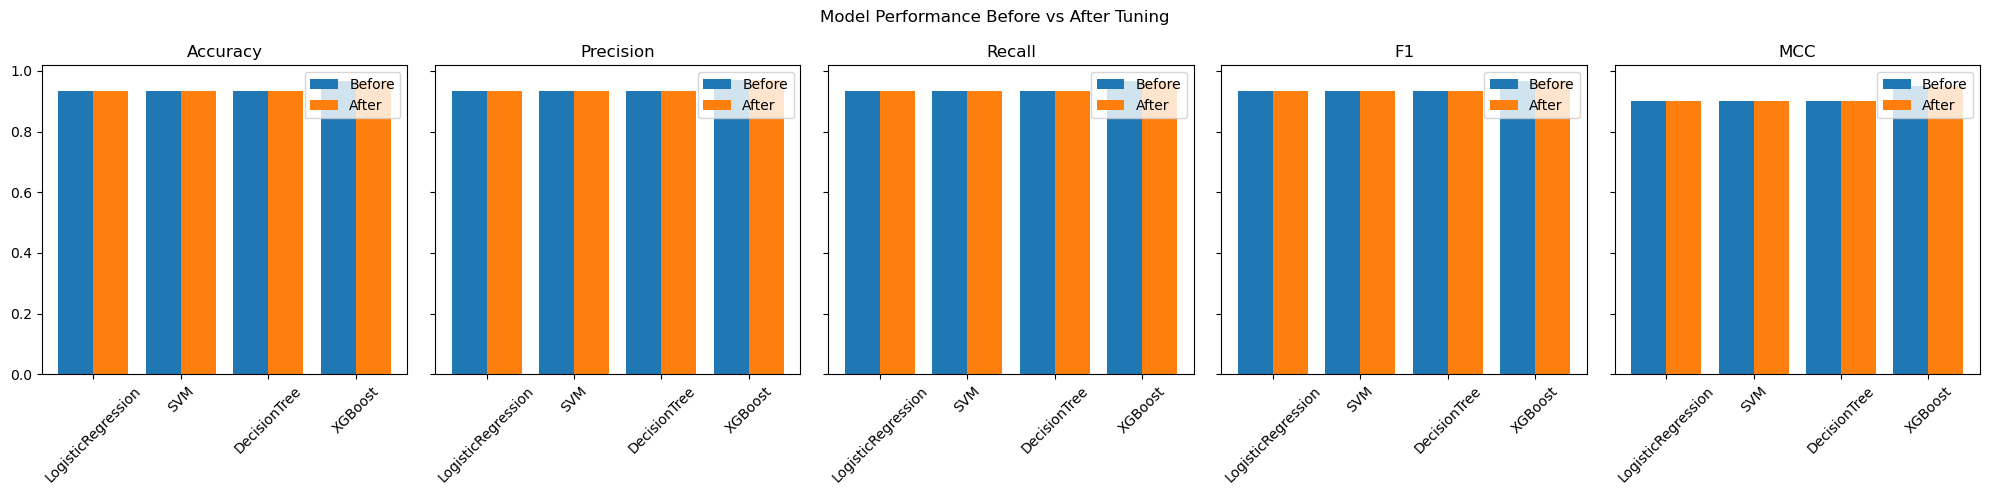

In [8]:
# 6. Plot comparison
fig, axes = plt.subplots(1, len(metrics), figsize=(20,5), sharey=True)
for i, metric in enumerate(metrics):
    before_vals = [results_before[m][metric] for m in models]
    after_vals = [results_after[m][metric] for m in models]
    x = np.arange(len(models))
    axes[i].bar(x-0.2, before_vals, width=0.4, label='Before')
    axes[i].bar(x+0.2, after_vals, width=0.4, label='After')
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(list(models.keys()), rotation=45)
    axes[i].set_title(metric)
    axes[i].legend()

plt.suptitle("Model Performance Before vs After Tuning")
plt.tight_layout()
plt.show()

## Feature importance in the best model

* Uses the feature selector (`SelectKBest`) to identify which features were kept.
* Retrieves their names from the Iris dataset (`iris.feature_names`).
* `features` is now a list of the selected feature names.


`hasattr` is a built-in function that checks wether an object has a specific attribute. It return **True** if the attribute exists, otherwise **False**

***BECAUSE***

* For **tree-based models** (like DecisionTree, RandomForest, XGBoost), they expose a property called `feature_importances_`.
* For **linear models** (like Logistic Regression, SVM), they expose a property called `coef_`.
* Since not all models have the same way of reporting feature importance, `hasattr` is used to check which attribute exists before trying to access it.

`zip(features, model.feature_importances_)`

Pairs each feature name with its corresponding importance score.

Example: [("sepal length", 0.25), ("petal width", 0.75)].

`dict(...)`

Converts those pairs into a dictionary.

Example: {"sepal length": 0.25, "petal width": 0.75}.

In [9]:
# After training each model (before and after tuning), check if it supports feature importance

features = [iris.feature_names[i] for i in selector.get_support(indices=True)]

# Before tuning
if hasattr(model, "feature_importances_"):
    print(f"{name} feature importance (before tuning):")
    print(dict(zip(features, model.feature_importances_)))

elif hasattr(model, "coef_"):
    print(f"{name} coefficients (before tuning):")
    print(dict(zip(features, np.abs(model.coef_).mean(axis=0))))

# After tuning
if hasattr(best_model, "feature_importances_"):
    print(f"{name} feature importance (after tuning):")
    print(dict(zip(features, best_model.feature_importances_)))

elif hasattr(best_model, "coef_"):
    print(f"{name} coefficients (after tuning):")
    print(dict(zip(features, np.abs(best_model.coef_).mean(axis=0))))

XGBoost feature importance (before tuning):
{'petal length (cm)': np.float32(0.5470395), 'petal width (cm)': np.float32(0.4529605)}
XGBoost feature importance (after tuning):
{'petal length (cm)': np.float32(0.4892317), 'petal width (cm)': np.float32(0.51076835)}


In [10]:
# Assume iris, selector, model, best_model, name are defined in your loop
features = [iris.feature_names[i] for i in selector.get_support(indices=True)]

def plot_feature_importance(name, model, best_model, features):
    fig, axes = plt.subplots(1, 2, figsize=(10,4))
    
    # Before tuning
    if hasattr(model, "feature_importances_"):
        importances_before = model.feature_importances_
        axes[0].bar(features, importances_before, color="skyblue")
        axes[0].set_title(f"{name} (Before tuning)")
        axes[0].set_ylabel("Importance")
    elif hasattr(model, "coef_"):
        importances_before = np.abs(model.coef_).mean(axis=0)
        axes[0].bar(features, importances_before, color="skyblue")
        axes[0].set_title(f"{name} (Before tuning)")
        axes[0].set_ylabel("Coefficient magnitude")

    # After tuning
    if hasattr(best_model, "feature_importances_"):
        importances_after = best_model.feature_importances_
        axes[1].bar(features, importances_after, color="salmon")
        axes[1].set_title(f"{name} (After tuning)")
        axes[1].set_ylabel("Importance")
    elif hasattr(best_model, "coef_"):
        importances_after = np.abs(best_model.coef_).mean(axis=0)
        axes[1].bar(features, importances_after, color="salmon")
        axes[1].set_title(f"{name} (After tuning)")
        axes[1].set_ylabel("Coefficient magnitude")

    plt.suptitle(f"Feature Importance Comparison for {name}")
    plt.tight_layout()
    plt.show()


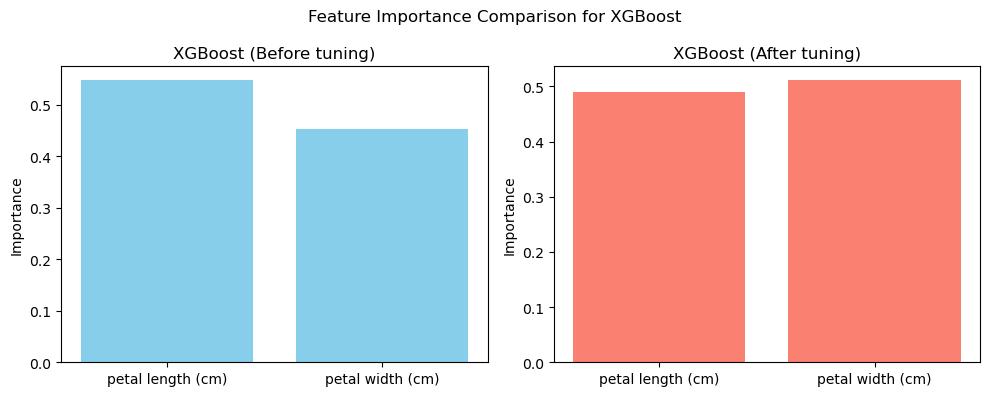

In [11]:
plot_feature_importance(name, model, best_model, features)